In [22]:
# Cell 1 — Setup
import sqlite3
import pandas as pd

DB_PATH = "../data/commodity_credit.db"
conn = sqlite3.connect(DB_PATH)

print("Connected to SQLite!")

# Helper function to run SQL and display results
def query(sql, display=True):
    df = pd.read_sql(sql, conn)
    if display:
        print(df.to_string(index=False))
    return df

print("Helper function loaded.")

Connected to SQLite!
Helper function loaded.


In [25]:
# BigQuery client — needed for dictionary lookups
from google.cloud import bigquery
client = bigquery.Client(project="commodity-credit-risk")
print("BigQuery client ready!")

C:\Users\elemt\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:255: FutureWarning: You are using a Python version (3.10.0) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
C:\Users\elemt\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:255: FutureWarning: You are using a Python version (3.10.0) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


BigQuery client ready!


In [2]:
# Cell 2 — BQ1: Risk profile by commodity
# Which commodity has the highest default rate?

print("=" * 60)
print("BUSINESS QUESTION 1: Risk profile by commodity")
print("=" * 60)

df_bq1 = query("""
    WITH operacoes_status AS (
        SELECT
            o.produto,
            o.id_referencia_bacen,
            o.numero_ordem,
            MAX(CASE
                WHEN s.id_situacao_operacao IN (2, 4, 5, 6, 8, 9, 12, 13)
                THEN 1 ELSE 0
            END) AS inadimplente,
            MAX(CASE
                WHEN s.id_situacao_operacao = 12 THEN 1 ELSE 0
            END) AS inadimplente_formal,
            AVG(o.valor_parcela_credito) AS valor_medio
        FROM operacoes o
        LEFT JOIN saldo s
            ON o.id_referencia_bacen = s.id_referencia_bacen
            AND o.numero_ordem = s.numero_ordem
        GROUP BY o.produto, o.id_referencia_bacen, o.numero_ordem
    )
    SELECT
        produto,
        COUNT(*) AS total_operacoes,
        ROUND(AVG(valor_medio), 2) AS ticket_medio,
        SUM(inadimplente) AS total_problematicas,
        ROUND(SUM(inadimplente) * 100.0 / COUNT(*), 2) AS taxa_problematica_pct,
        SUM(inadimplente_formal) AS total_inadimplentes,
        ROUND(SUM(inadimplente_formal) * 100.0 / COUNT(*), 2) AS taxa_inadimplencia_pct
    FROM operacoes_status
    GROUP BY produto
    ORDER BY taxa_inadimplencia_pct DESC
""")

BUSINESS QUESTION 1: Risk profile by commodity
       produto  total_operacoes  ticket_medio  total_problematicas  taxa_problematica_pct  total_inadimplentes  taxa_inadimplencia_pct
CANA-DE-AÇUCAR            87522     517058.89                 1696                   1.94                  859                    0.98
       LARANJA            24371     313043.10                  367                   1.51                  160                    0.66
          CAFÉ           388107     197152.13                 5236                   1.35                 1790                    0.46


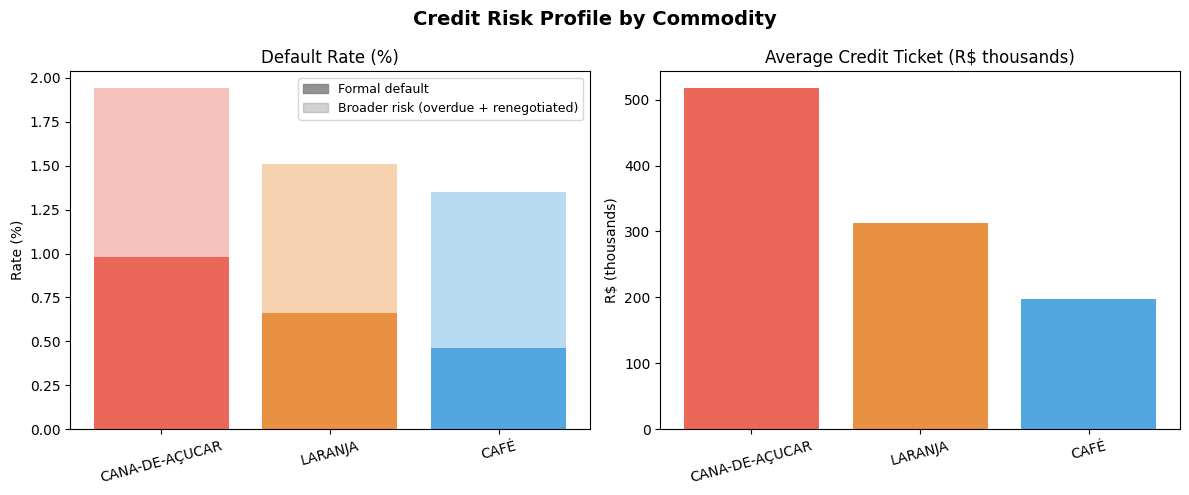

Saved!


In [3]:
# Cell 3 — BQ1 Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Credit Risk Profile by Commodity", fontsize=14, fontweight="bold")

produtos = df_bq1["produto"]
colors = ["#E74C3C", "#E67E22", "#3498DB"]

# Chart 1 — Default rates
axes[0].bar(produtos, df_bq1["taxa_inadimplencia_pct"], color=colors, alpha=0.85)
axes[0].bar(produtos, df_bq1["taxa_problematica_pct"] - df_bq1["taxa_inadimplencia_pct"],
            bottom=df_bq1["taxa_inadimplencia_pct"], color=colors, alpha=0.35)
axes[0].set_title("Default Rate (%)")
axes[0].set_ylabel("Rate (%)")
axes[0].tick_params(axis="x", rotation=15)

formal = mpatches.Patch(alpha=0.85, color="gray", label="Formal default")
broader = mpatches.Patch(alpha=0.35, color="gray", label="Broader risk (overdue + renegotiated)")
axes[0].legend(handles=[formal, broader], fontsize=9)

# Chart 2 — Average ticket
axes[1].bar(produtos, df_bq1["ticket_medio"] / 1000, color=colors, alpha=0.85)
axes[1].set_title("Average Credit Ticket (R$ thousands)")
axes[1].set_ylabel("R$ (thousands)")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("../data/bq1_risk_by_commodity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

In [4]:
# Cell 4 — BQ2: Regional risk
print("=" * 60)
print("BUSINESS QUESTION 2: Regional credit risk")
print("=" * 60)

df_bq2 = query("""
    WITH operacoes_status AS (
        SELECT
            o.produto,
            o.sigla_uf,
            o.id_referencia_bacen,
            o.numero_ordem,
            MAX(CASE
                WHEN s.id_situacao_operacao IN (2, 4, 5, 6, 8, 9, 12, 13)
                THEN 1 ELSE 0
            END) AS inadimplente,
            AVG(o.valor_parcela_credito) AS valor_medio
        FROM operacoes o
        LEFT JOIN saldo s
            ON o.id_referencia_bacen = s.id_referencia_bacen
            AND o.numero_ordem = s.numero_ordem
        WHERE o.sigla_uf IS NOT NULL
        GROUP BY o.produto, o.sigla_uf, o.id_referencia_bacen, o.numero_ordem
    )
    SELECT
        sigla_uf,
        produto,
        COUNT(*) AS total_operacoes,
        ROUND(AVG(valor_medio), 2) AS ticket_medio,
        SUM(inadimplente) AS total_problematicas,
        ROUND(SUM(inadimplente) * 100.0 / COUNT(*), 2) AS taxa_risco_pct
    FROM operacoes_status
    GROUP BY sigla_uf, produto
    HAVING total_operacoes >= 100
    ORDER BY taxa_risco_pct DESC
    LIMIT 20
""")

BUSINESS QUESTION 2: Regional credit risk
sigla_uf        produto  total_operacoes  ticket_medio  total_problematicas  taxa_risco_pct
      SE CANA-DE-AÇUCAR              318     239501.85                   36           11.32
      AC           CAFÉ              100     133635.27                    7            7.00
      PE CANA-DE-AÇUCAR            11056     139304.29                  614            5.55
      PE        LARANJA              221       7052.28                   12            5.43
      ES CANA-DE-AÇUCAR              247     316944.83                   11            4.45
      AL CANA-DE-AÇUCAR             6622     199067.99                  234            3.53
      RJ CANA-DE-AÇUCAR              223     177436.71                    7            3.14
      BA        LARANJA             3760      39785.11                   98            2.61
      RJ           CAFÉ             1452      69403.11                   34            2.34
      GO        LARANJA              1

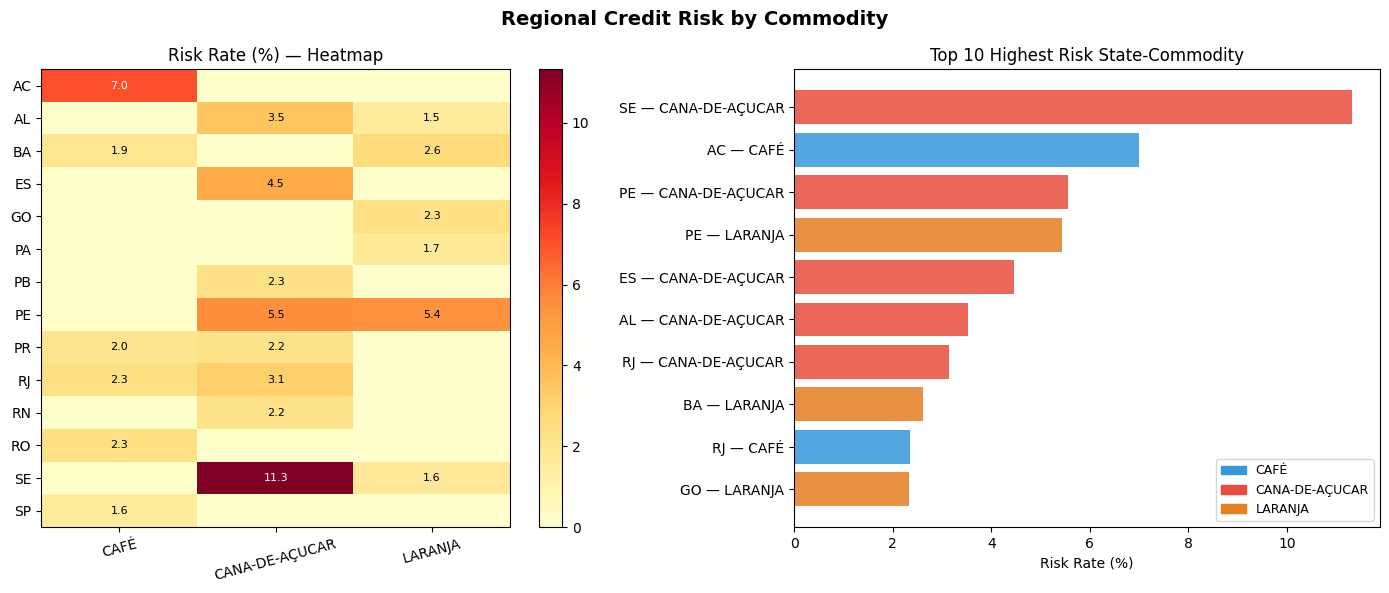

Saved!


In [5]:
# Cell 5 — BQ2 Visualization
import numpy as np

# Pivot for heatmap
df_pivot = df_bq2.pivot_table(
    values="taxa_risco_pct",
    index="sigla_uf",
    columns="produto",
    fill_value=0
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Regional Credit Risk by Commodity", fontsize=14, fontweight="bold")

# Heatmap
im = axes[0].imshow(df_pivot.values, cmap="YlOrRd", aspect="auto")
axes[0].set_xticks(range(len(df_pivot.columns)))
axes[0].set_xticklabels(df_pivot.columns, rotation=15)
axes[0].set_yticks(range(len(df_pivot.index)))
axes[0].set_yticklabels(df_pivot.index)
axes[0].set_title("Risk Rate (%) — Heatmap")
plt.colorbar(im, ax=axes[0])

for i in range(len(df_pivot.index)):
    for j in range(len(df_pivot.columns)):
        val = df_pivot.values[i, j]
        if val > 0:
            axes[0].text(j, i, f"{val:.1f}",
                        ha="center", va="center", fontsize=8,
                        color="black" if val < 6 else "white")

# Top 10 states bar chart
df_top10 = df_bq2.head(10).copy()
colors_map = {"CAFÉ": "#3498DB", "CANA-DE-AÇUCAR": "#E74C3C", "LARANJA": "#E67E22"}
bar_colors = [colors_map[p] for p in df_top10["produto"]]

axes[1].barh(
    df_top10["sigla_uf"] + " — " + df_top10["produto"],
    df_top10["taxa_risco_pct"],
    color=bar_colors, alpha=0.85
)
axes[1].set_title("Top 10 Highest Risk State-Commodity")
axes[1].set_xlabel("Risk Rate (%)")
axes[1].invert_yaxis()

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in colors_map.items()]
axes[1].legend(handles=legend_patches, fontsize=9)

plt.tight_layout()
plt.savefig("../data/bq2_regional_risk.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

In [8]:
# Cell 6 — BQ2 Brazil Maps by Commodity
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import urllib.request
import zipfile
import os

# Download Brazil states shapefile
shapefile_url = "https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2022/Brasil/BR/BR_UF_2022.zip"
zip_path = "../data/BR_UF_2022.zip"
shp_dir = "../data/shapefiles"

if not os.path.exists(shp_dir):
    print("Downloading shapefile...")
    urllib.request.urlretrieve(shapefile_url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(shp_dir)
    print("Downloaded!")

# Load shapefile
gdf = gpd.read_file(f"{shp_dir}/BR_UF_2022.shp")
gdf = gdf.rename(columns={"SIGLA_UF": "sigla_uf"})
print(f"Shapefile loaded: {len(gdf)} states")
print(gdf[['sigla_uf', 'NM_UF']].head())

Shapefile loaded: 27 states
  sigla_uf      NM_UF
0       AC       Acre
1       AM   Amazonas
2       PA       Pará
3       AP      Amapá
4       TO  Tocantins


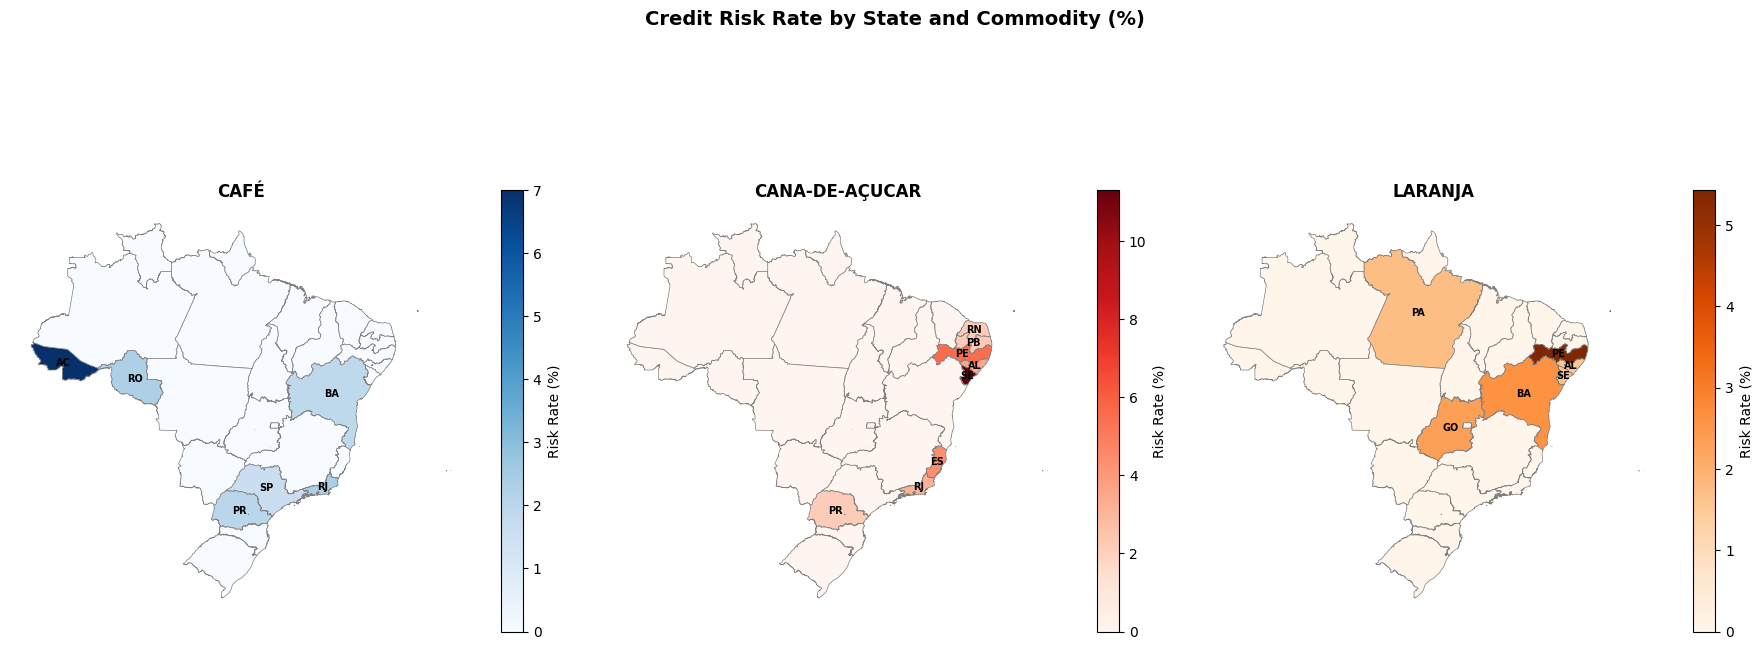

Saved!


In [10]:
# Cell 7 — Brazil Maps by Commodity (clean version)
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
fig.suptitle("Credit Risk Rate by State and Commodity (%)", fontsize=14, fontweight="bold")

commodities = ["CAFÉ", "CANA-DE-AÇUCAR", "LARANJA"]
cmaps = ["Blues", "Reds", "Oranges"]

for ax, commodity, cmap in zip(axes, commodities, cmaps):
    df_commodity = df_bq2[df_bq2["produto"] == commodity][["sigla_uf", "taxa_risco_pct"]]
    gdf_merged = gdf.merge(df_commodity, on="sigla_uf", how="left")
    gdf_merged["taxa_risco_pct"] = gdf_merged["taxa_risco_pct"].fillna(0)

    gdf_merged.plot(
        column="taxa_risco_pct",
        cmap=cmap,
        linewidth=0.5,
        edgecolor="gray",
        ax=ax,
        legend=True,
        legend_kwds={"label": "Risk Rate (%)", "shrink": 0.6}
    )

    # Only label states with risk > 0
    for _, row in gdf_merged.iterrows():
        if row["taxa_risco_pct"] > 0:
            centroid = row.geometry.centroid
            ax.annotate(
                row["sigla_uf"],
                xy=(centroid.x, centroid.y),
                ha="center", va="center",
                fontsize=7, fontweight="bold",
                color="black"
            )

    ax.set_title(commodity, fontsize=12, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.savefig("../data/bq2_brazil_maps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")


In [11]:
# Cell 8 — BQ3: Financial anomalies
print("=" * 60)
print("BUSINESS QUESTION 3: Financial anomalies detection")
print("=" * 60)

df_bq3 = query("""
    WITH stats AS (
        SELECT
            produto,
            AVG(valor_parcela_credito) AS media,
            AVG(valor_parcela_credito * valor_parcela_credito) - 
                AVG(valor_parcela_credito) * AVG(valor_parcela_credito) AS variancia
        FROM operacoes
        WHERE valor_parcela_credito > 0
        GROUP BY produto
    ),
    zscore AS (
        SELECT
            o.produto,
            o.sigla_uf,
            o.id_referencia_bacen,
            o.numero_ordem,
            o.valor_parcela_credito,
            o.taxa_juro,
            o.valor_receita_bruta_esperada,
            o.valor_produtividade_obtida,
            (o.valor_parcela_credito - s.media) / 
                SQRT(s.variancia + 0.0001) AS zscore_valor
        FROM operacoes o
        JOIN stats s ON o.produto = s.produto
        WHERE o.valor_parcela_credito > 0
    )
    SELECT
        produto,
        sigla_uf,
        COUNT(*) AS total_anomalias,
        ROUND(AVG(valor_parcela_credito), 2) AS ticket_medio_anomalias,
        ROUND(AVG(taxa_juro), 4) AS taxa_juro_media,
        ROUND(AVG(zscore_valor), 2) AS zscore_medio
    FROM zscore
    WHERE ABS(zscore_valor) > 3
    GROUP BY produto, sigla_uf
    HAVING total_anomalias >= 5
    ORDER BY total_anomalias DESC
    LIMIT 15
""")

BUSINESS QUESTION 3: Financial anomalies detection
       produto sigla_uf  total_anomalias  ticket_medio_anomalias  taxa_juro_media  zscore_medio
          CAFÉ       MG             1420             10525562.61           8.2399          8.61
          CAFÉ       ES              292              7958886.27           8.9288          6.47
          CAFÉ       SP              268             12774180.00           8.9927         10.48
          CAFÉ       PR              118             10622377.88           8.8842          8.69
       LARANJA       SP              115             10470698.35          10.8349          7.85
CANA-DE-AÇUCAR       SP              109            101165750.87           5.8345         12.38
          CAFÉ       BA               27              5805047.05           7.2004          4.67
CANA-DE-AÇUCAR       MG               15             42583791.62           5.2860          5.17
CANA-DE-AÇUCAR       MT               15             61033333.33          10.4440    

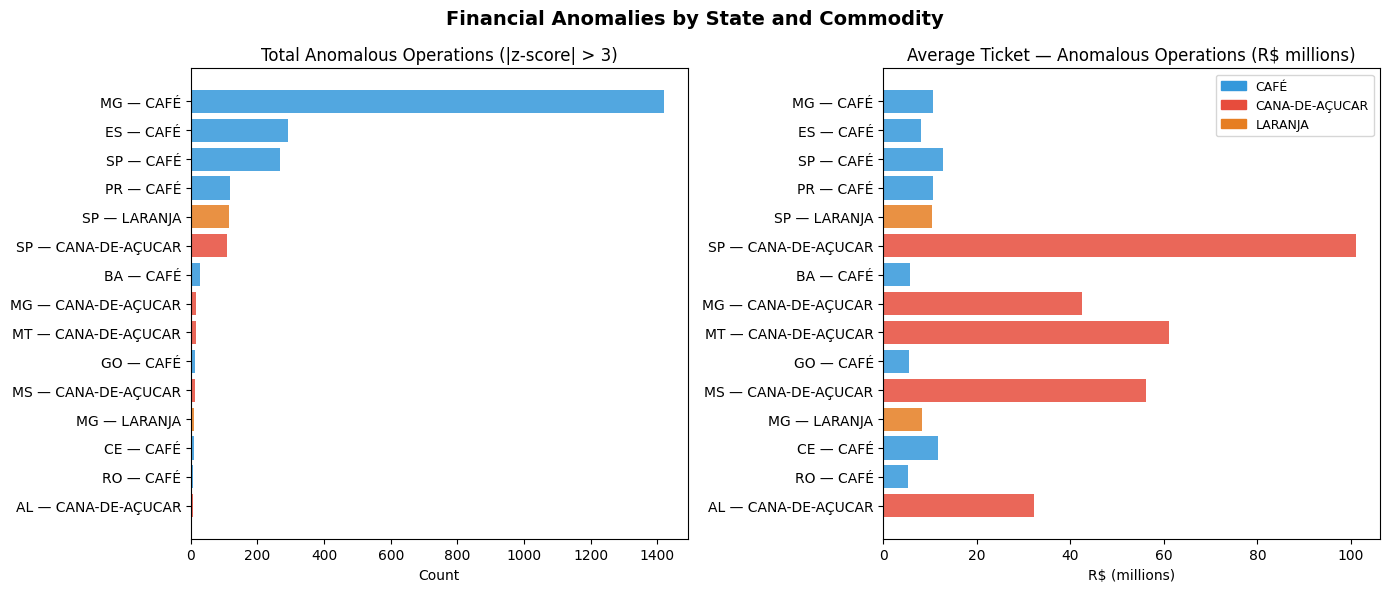

Saved!


In [12]:
# Cell 9 — BQ3 Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Financial Anomalies by State and Commodity", fontsize=14, fontweight="bold")

colors_map = {"CAFÉ": "#3498DB", "CANA-DE-AÇUCAR": "#E74C3C", "LARANJA": "#E67E22"}
bar_colors = [colors_map[p] for p in df_bq3["produto"]]
labels = df_bq3["sigla_uf"] + " — " + df_bq3["produto"]

# Chart 1 — Total anomalies
axes[0].barh(labels, df_bq3["total_anomalias"], color=bar_colors, alpha=0.85)
axes[0].set_title("Total Anomalous Operations (|z-score| > 3)")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()

# Chart 2 — Average ticket of anomalies
axes[1].barh(labels, df_bq3["ticket_medio_anomalias"] / 1e6, color=bar_colors, alpha=0.85)
axes[1].set_title("Average Ticket — Anomalous Operations (R$ millions)")
axes[1].set_xlabel("R$ (millions)")
axes[1].invert_yaxis()

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in colors_map.items()]
axes[1].legend(handles=legend_patches, fontsize=9)

plt.tight_layout()
plt.savefig("../data/bq3_anomalies.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

In [13]:
# Cell 10 — BQ4: Seasonality
print("=" * 60)
print("BUSINESS QUESTION 4: Seasonality — risk by year")
print("=" * 60)

df_bq4 = query("""
    WITH operacoes_status AS (
        SELECT
            o.produto,
            o.ano_emissao,
            o.id_referencia_bacen,
            o.numero_ordem,
            MAX(CASE
                WHEN s.id_situacao_operacao IN (2, 4, 5, 6, 8, 9, 12, 13)
                THEN 1 ELSE 0
            END) AS inadimplente,
            AVG(o.valor_parcela_credito) AS valor_medio
        FROM operacoes o
        LEFT JOIN saldo s
            ON o.id_referencia_bacen = s.id_referencia_bacen
            AND o.numero_ordem = s.numero_ordem
        GROUP BY o.produto, o.ano_emissao, o.id_referencia_bacen, o.numero_ordem
    )
    SELECT
        ano_emissao,
        produto,
        COUNT(*) AS total_operacoes,
        ROUND(AVG(valor_medio), 2) AS ticket_medio,
        SUM(inadimplente) AS total_problematicas,
        ROUND(SUM(inadimplente) * 100.0 / COUNT(*), 2) AS taxa_risco_pct
    FROM operacoes_status
    GROUP BY ano_emissao, produto
    ORDER BY ano_emissao, produto
""")

BUSINESS QUESTION 4: Seasonality — risk by year
 ano_emissao        produto  total_operacoes  ticket_medio  total_problematicas  taxa_risco_pct
        2018           CAFÉ            72308     127119.90                 2408            3.33
        2018 CANA-DE-AÇUCAR            16503     405166.89                  717            4.34
        2018        LARANJA             4161     221903.48                  159            3.82
        2019           CAFÉ            65868     142390.82                 1602            2.43
        2019 CANA-DE-AÇUCAR            13652     356245.04                  346            2.53
        2019        LARANJA             3701     218186.55                   89            2.40
        2020           CAFÉ            46339     166577.93                  238            0.51
        2020 CANA-DE-AÇUCAR            12707     334743.12                  199            1.57
        2020        LARANJA             3852     249216.67                   56         

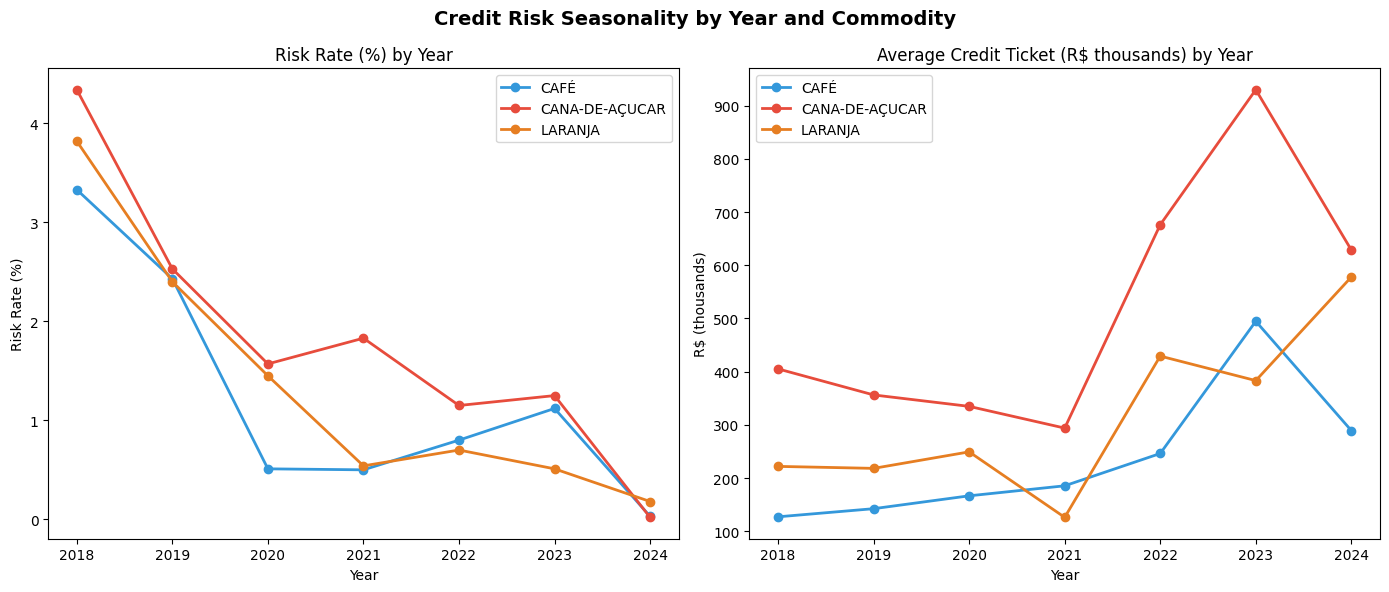

Saved!


In [16]:
# Cell 11 — BQ4 Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Credit Risk Seasonality by Year and Commodity", fontsize=14, fontweight="bold")

colors_map = {"CAFÉ": "#3498DB", "CANA-DE-AÇUCAR": "#E74C3C", "LARANJA": "#E67E22"}

for produto, color in colors_map.items():
    df_prod = df_bq4[df_bq4["produto"] == produto]
    
    # Chart 1 — Risk rate over time
    axes[0].plot(
        df_prod["ano_emissao"], df_prod["taxa_risco_pct"],
        marker="o", label=produto, color=color, linewidth=2
    )
    
    # Chart 2 — Average ticket over time
    axes[1].plot(
        df_prod["ano_emissao"], df_prod["ticket_medio"] / 1000,
        marker="o", label=produto, color=color, linewidth=2
    )

axes[0].set_title("Risk Rate (%) by Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Risk Rate (%)")
axes[0].legend()
#axes[0].grid(False, alpha=0.3)

axes[1].set_title("Average Credit Ticket (R$ thousands) by Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("R$ (thousands)")
axes[1].legend()
#axes[1].grid(False, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/bq4_seasonality.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

BQ4 EXTENSION: Year-over-Year Risk Variation
 ano_emissao        produto  taxa_risco_pct  variacao_yoy_pp  variacao_yoy_pct
        2019           CAFÉ            2.43            -0.90             -27.0
        2020           CAFÉ            0.51            -1.92             -79.0
        2021           CAFÉ            0.50            -0.01              -2.0
        2022           CAFÉ            0.80             0.30              60.0
        2023           CAFÉ            1.12             0.32              40.0
        2024           CAFÉ            0.03            -1.09             -97.3
        2019 CANA-DE-AÇUCAR            2.53            -1.81             -41.7
        2020 CANA-DE-AÇUCAR            1.57            -0.96             -37.9
        2021 CANA-DE-AÇUCAR            1.83             0.26              16.6
        2022 CANA-DE-AÇUCAR            1.15            -0.68             -37.2
        2023 CANA-DE-AÇUCAR            1.25             0.10               8.7
       

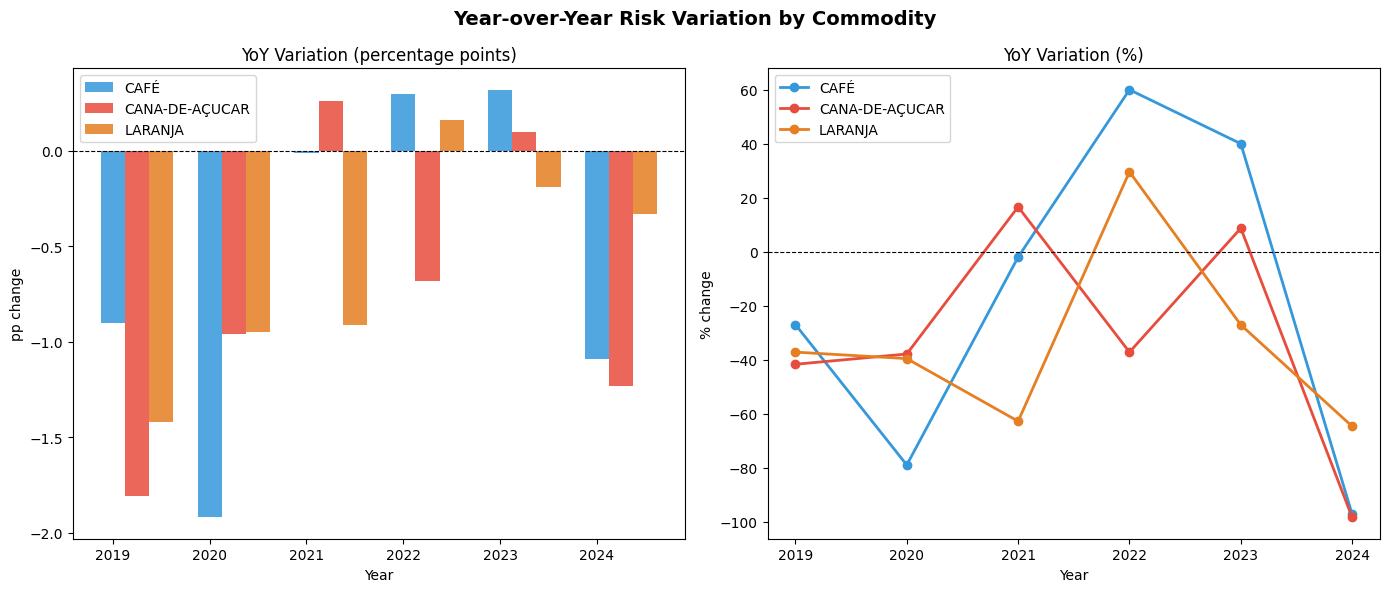

Saved!


In [18]:
# Cell 12 — BQ4 Year-over-Year variation
print("=" * 60)
print("BQ4 EXTENSION: Year-over-Year Risk Variation")
print("=" * 60)

df_yoy = df_bq4.copy()
df_yoy = df_yoy.sort_values(["produto", "ano_emissao"])

# Calculate YoY variation
df_yoy["taxa_risco_anterior"] = df_yoy.groupby("produto")["taxa_risco_pct"].shift(1)
df_yoy["variacao_yoy_pp"] = df_yoy["taxa_risco_pct"] - df_yoy["taxa_risco_anterior"]
df_yoy["variacao_yoy_pct"] = (df_yoy["variacao_yoy_pp"] / df_yoy["taxa_risco_anterior"] * 100).round(1)

print(df_yoy[["ano_emissao", "produto", "taxa_risco_pct", 
              "variacao_yoy_pp", "variacao_yoy_pct"]].dropna().to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Year-over-Year Risk Variation by Commodity", fontsize=14, fontweight="bold")

for produto, color in colors_map.items():
    df_prod = df_yoy[df_yoy["produto"] == produto].dropna()
    
    # Chart 1 — YoY variation in percentage points
    axes[0].bar(
        df_prod["ano_emissao"] + list(colors_map.keys()).index(produto) * 0.25,
        df_prod["variacao_yoy_pp"],
        width=0.25, label=produto, color=color, alpha=0.85
    )
    
    # Chart 2 — YoY variation in %
    axes[1].plot(
        df_prod["ano_emissao"], df_prod["variacao_yoy_pct"],
        marker="o", label=produto, color=color, linewidth=2
    )

axes[0].axhline(y=0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("YoY Variation (percentage points)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("pp change")
axes[0].legend()


axes[1].axhline(y=0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("YoY Variation (%)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("% change")
axes[1].legend()


plt.tight_layout()
plt.savefig("../data/bq4_yoy_variation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

In [19]:
# Cell 13 — BQ5: Default predictor profile
print("=" * 60)
print("BUSINESS QUESTION 5: Default predictor profile")
print("=" * 60)

df_bq5 = query("""
    WITH operacoes_status AS (
        SELECT
            o.produto,
            o.id_fonte_recurso,
            o.id_tipo_agricultura,
            o.id_tipo_cultivo,
            o.valor_parcela_credito,
            o.taxa_juro,
            o.valor_receita_bruta_esperada,
            CAST(
                JULIANDAY(o.data_vencimento) - JULIANDAY(o.data_emissao)
                AS INTEGER
            ) AS prazo_dias,
            MAX(CASE
                WHEN s.id_situacao_operacao IN (2, 4, 5, 6, 8, 9, 12, 13)
                THEN 1 ELSE 0
            END) AS inadimplente
        FROM operacoes o
        LEFT JOIN saldo s
            ON o.id_referencia_bacen = s.id_referencia_bacen
            AND o.numero_ordem = s.numero_ordem
        WHERE o.valor_parcela_credito > 0
          AND o.taxa_juro > 0
        GROUP BY
            o.produto, o.id_fonte_recurso, o.id_tipo_agricultura,
            o.id_tipo_cultivo, o.valor_parcela_credito, o.taxa_juro,
            o.valor_receita_bruta_esperada, o.data_vencimento, o.data_emissao
    )
    SELECT
        id_fonte_recurso,
        COUNT(*) AS total,
        ROUND(AVG(valor_parcela_credito), 2) AS ticket_medio,
        ROUND(AVG(taxa_juro), 4) AS taxa_juro_media,
        ROUND(AVG(prazo_dias), 0) AS prazo_medio_dias,
        SUM(inadimplente) AS total_inadimplentes,
        ROUND(SUM(inadimplente) * 100.0 / COUNT(*), 2) AS taxa_risco_pct
    FROM operacoes_status
    GROUP BY id_fonte_recurso
    HAVING total >= 1000
    ORDER BY taxa_risco_pct DESC
    LIMIT 15
""")

BUSINESS QUESTION 5: Default predictor profile
id_fonte_recurso  total  ticket_medio  taxa_juro_media  prazo_medio_dias  total_inadimplentes  taxa_risco_pct
             450   1508      52923.82           4.5718            3031.0                   92            6.10
             501   2007     130330.68           3.6141            1849.0                   70            3.49
             502  25539     133228.24           1.9527            1320.0                  818            3.20
             440   4353     744651.86           8.6973             569.0                  137            3.15
             202   1117     148267.63           6.0000             407.0                   34            3.04
             201 113631     226274.28           6.1530             502.0                 2689            2.37
             304   6803      51287.82           4.9428             320.0                  137            2.01
             430  32562     925064.16          12.1367             558.0 

In [26]:
# Check dicionario for fonte_recurso
query_fonte = """
SELECT *
FROM `basedosdados.br_bcb_sicor.dicionario`
WHERE nome_coluna = 'id_fonte_recurso'
ORDER BY chave
"""

df_fonte_dic = client.query(query_fonte).to_dataframe()
print(df_fonte_dic[['chave', 'valor']].to_string(index=False))

chave                                                                                        valor
  100                                                                             TESOURO NACIONAL
  201                                                                       OBRIGATÓRIOS - MCR 6.2
  202                                                 EXIGIBILIDADE ADICIONAL DOS RECURSOS À VISTA
  222                      Exigibilidade Adicional dos Recursos à Vista - Resolução 5030 ENCERRADO
  225                    Exigibilidade Adicional dos Recursos à Vista - Resolução 5087 - ENCERRADO
  226                                Exigibilidade Adicional dos Recursos à Vista - Resolução 5157
  250                                                         FACULDADE DE APLICAÇÃO - COMPULSÓRIO
  260                    COMPULSÓRIO SOBRE RECURSOS À VISTA - REFORÇO DO INVESTIMENTO (CIRC 3.745)
  300                                           POUPANÇA RURAL - CONTROLADOS - SUBVENÇÃO ECONÔMICA
  301     

In [29]:
# Save fonte_recurso dictionary to SQLite
df_fonte_dic.to_sql("dicionario_fonte_recurso", conn, if_exists="replace", index=False)

# Create readable labels for BQ5
fonte_map = dict(zip(df_fonte_dic["chave"].astype(str), df_fonte_dic["valor"]))

def shorten_label(label, max_len=40):
    if not isinstance(label, str):
        return "Unknown"
    return label[:max_len] + "..." if len(label) > max_len else label

df_bq5["fonte_label"] = df_bq5["id_fonte_recurso"].astype(str).map(fonte_map).apply(shorten_label)

print(df_bq5[["id_fonte_recurso", "fonte_label", "taxa_risco_pct"]].to_string(index=False))

id_fonte_recurso                                 fonte_label  taxa_risco_pct
             450 INSTR HIBRIDO CAPITAL DÍVIDA-IHCD (Lei 1...            6.10
             501 FUNDO CONSTITUCIONAL DE FINANCIAMENTO DO...            3.49
             502 FUNDO CONSTITUCIONAL DE FINANCIAMENTO DO...            3.20
             440 LETRA DE CRÉDITO DO AGRONEGÓCIO (LCA) - ...            3.15
             202 EXIGIBILIDADE ADICIONAL DOS RECURSOS À V...            3.04
             201                      OBRIGATÓRIOS - MCR 6.2            2.37
             304 EXIGIBILIDADE ADICIONAL DA POUPANÇA RURA...            2.01
             430 LETRA DE CRÉDITO DO AGRONEGÓCIO (LCA) - ...            1.24
             300 POUPANÇA RURAL - CONTROLADOS - SUBVENÇÃO...            1.10
             402                             RECURSOS LIVRES            0.99
             303                      POUPANÇA RURAL - LIVRE            0.84
             800 FUNCAFE-FUNDO DE DEFESA DA ECONOMIA CAFE...            0.67

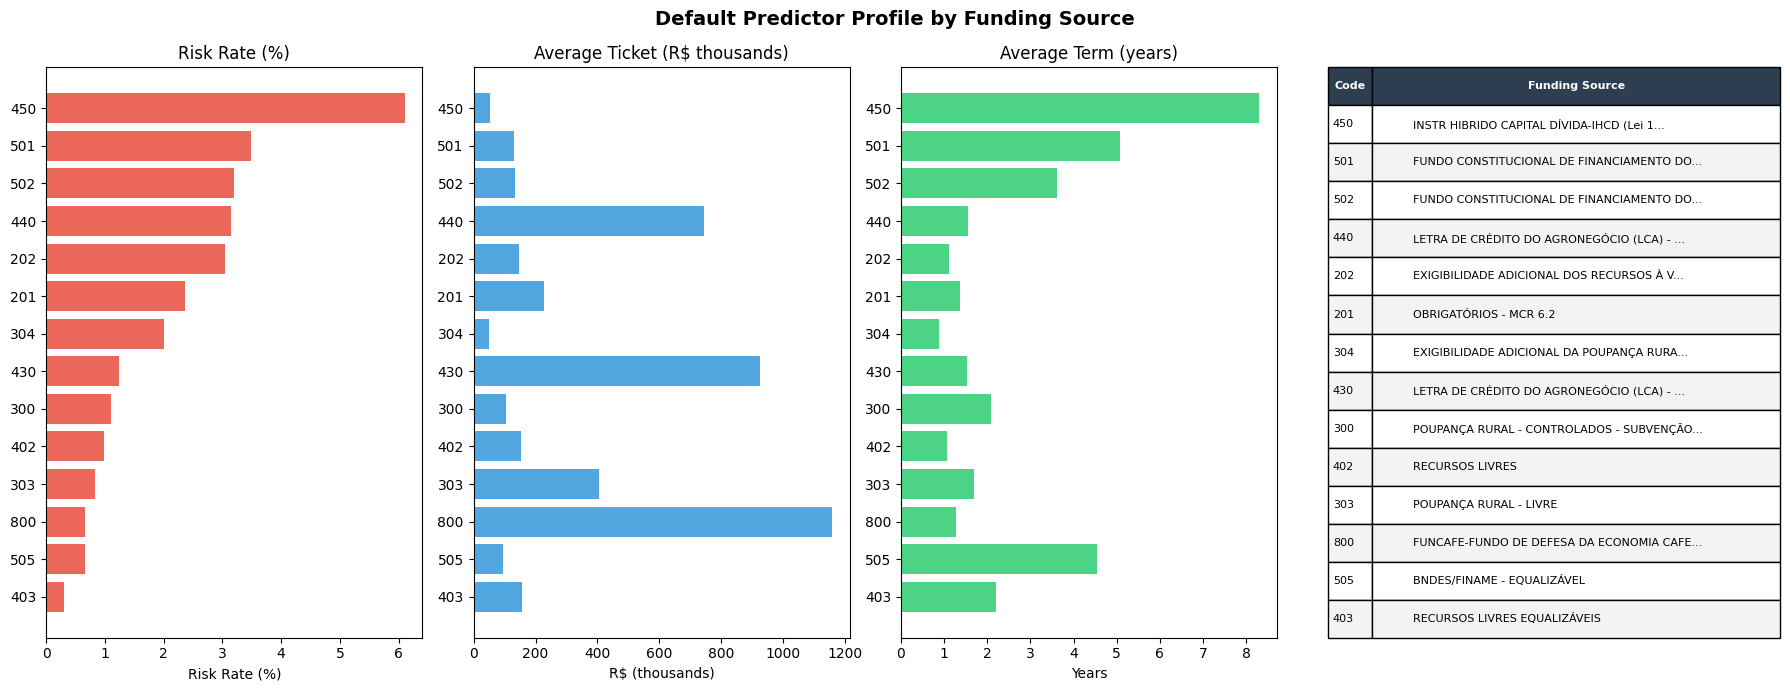

Saved!


In [30]:
# Cell 15 — BQ5 Visualization with legend table
fig = plt.figure(figsize=(18, 7))
fig.suptitle("Default Predictor Profile by Funding Source", fontsize=14, fontweight="bold")

# Grid: 3 charts + 1 legend table
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 1.2])
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])
ax4 = fig.add_subplot(gs[3])

labels_num = df_bq5["id_fonte_recurso"].astype(str)

# Chart 1 — Risk rate
ax1.barh(labels_num, df_bq5["taxa_risco_pct"], color="#E74C3C", alpha=0.85)
ax1.set_title("Risk Rate (%)")
ax1.set_xlabel("Risk Rate (%)")
ax1.invert_yaxis()

# Chart 2 — Average ticket
ax2.barh(labels_num, df_bq5["ticket_medio"] / 1000, color="#3498DB", alpha=0.85)
ax2.set_title("Average Ticket (R$ thousands)")
ax2.set_xlabel("R$ (thousands)")
ax2.invert_yaxis()

# Chart 3 — Average term
ax3.barh(labels_num, df_bq5["prazo_medio_dias"] / 365, color="#2ECC71", alpha=0.85)
ax3.set_title("Average Term (years)")
ax3.set_xlabel("Years")
ax3.invert_yaxis()

# Legend table
ax4.axis("off")
table_data = [[str(row["id_fonte_recurso"]), row["fonte_label"]]
              for _, row in df_bq5.iterrows()]
table = ax4.table(
    cellText=table_data,
    colLabels=["Code", "Funding Source"],
    cellLoc="left",
    loc="center",
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.auto_set_column_width([0, 1])

# Header style
for j in range(2):
    table[0, j].set_facecolor("#2C3E50")
    table[0, j].set_text_props(color="white", fontweight="bold")

# Alternating row colors
for i in range(1, len(table_data) + 1):
    for j in range(2):
        table[i, j].set_facecolor("#F2F3F4" if i % 2 == 0 else "white")

plt.tight_layout()
plt.savefig("../data/bq5_predictor_profile.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

In [31]:
# Cell 16 — BQ6: Program impact
print("=" * 60)
print("BUSINESS QUESTION 6: Program impact on credit risk")
print("=" * 60)

df_bq6 = query("""
    WITH operacoes_status AS (
        SELECT
            o.produto,
            o.id_programa,
            o.valor_parcela_credito,
            o.taxa_juro,
            MAX(CASE
                WHEN s.id_situacao_operacao IN (2, 4, 5, 6, 8, 9, 12, 13)
                THEN 1 ELSE 0
            END) AS inadimplente
        FROM operacoes o
        LEFT JOIN saldo s
            ON o.id_referencia_bacen = s.id_referencia_bacen
            AND o.numero_ordem = s.numero_ordem
        WHERE o.id_programa IS NOT NULL
        GROUP BY
            o.produto, o.id_programa, o.valor_parcela_credito, o.taxa_juro
    )
    SELECT
        id_programa,
        COUNT(*) AS total_operacoes,
        ROUND(AVG(valor_parcela_credito), 2) AS ticket_medio,
        ROUND(AVG(taxa_juro), 4) AS taxa_juro_media,
        SUM(inadimplente) AS total_problematicas,
        ROUND(SUM(inadimplente) * 100.0 / COUNT(*), 2) AS taxa_risco_pct
    FROM operacoes_status
    GROUP BY id_programa
    HAVING total_operacoes >= 500
    ORDER BY taxa_risco_pct DESC
    LIMIT 15
""")

BUSINESS QUESTION 6: Program impact on credit risk
id_programa  total_operacoes  ticket_medio  taxa_juro_media  total_problematicas  taxa_risco_pct
          1           138724      49018.55           4.8873                 3829            2.76
        999            86217     715591.71          11.1338                 1558            1.81
         70             6375    2253599.85           7.7316                  113            1.77
         50            57859     247196.58           6.6770                  811            1.40
        156              858     768196.74           6.9700                    5            0.58


In [32]:
# Cell 17 — BQ6 Dictionary + Visualization
query_programa = """
SELECT chave, valor
FROM `basedosdados.br_bcb_sicor.dicionario`
WHERE nome_coluna = 'id_programa'
ORDER BY chave
"""

df_programa_dic = client.query(query_programa).to_dataframe()
programa_map = dict(zip(df_programa_dic["chave"].astype(str), df_programa_dic["valor"]))

df_bq6["programa_label"] = df_bq6["id_programa"].astype(str).map(programa_map).apply(shorten_label)
print(df_bq6[["id_programa", "programa_label", "taxa_risco_pct"]].to_string(index=False))

id_programa                              programa_label  taxa_risco_pct
          1 PRONAF - PROGRAMA NACIONAL DE FORTALECIM...            2.76
        999 FINANCIAMENTO SEM VÍNCULO A PROGRAMA ESP...            1.81
         70 FUNCAFÉ (PROGRAMA DE DEFESA DA ECONOMIA ...            1.77
         50 PRONAMP - PROGRAMA NACIONAL DE APOIO AO ...            1.40
        156 ABC + Programa para a Adaptação à Mudanç...            0.58


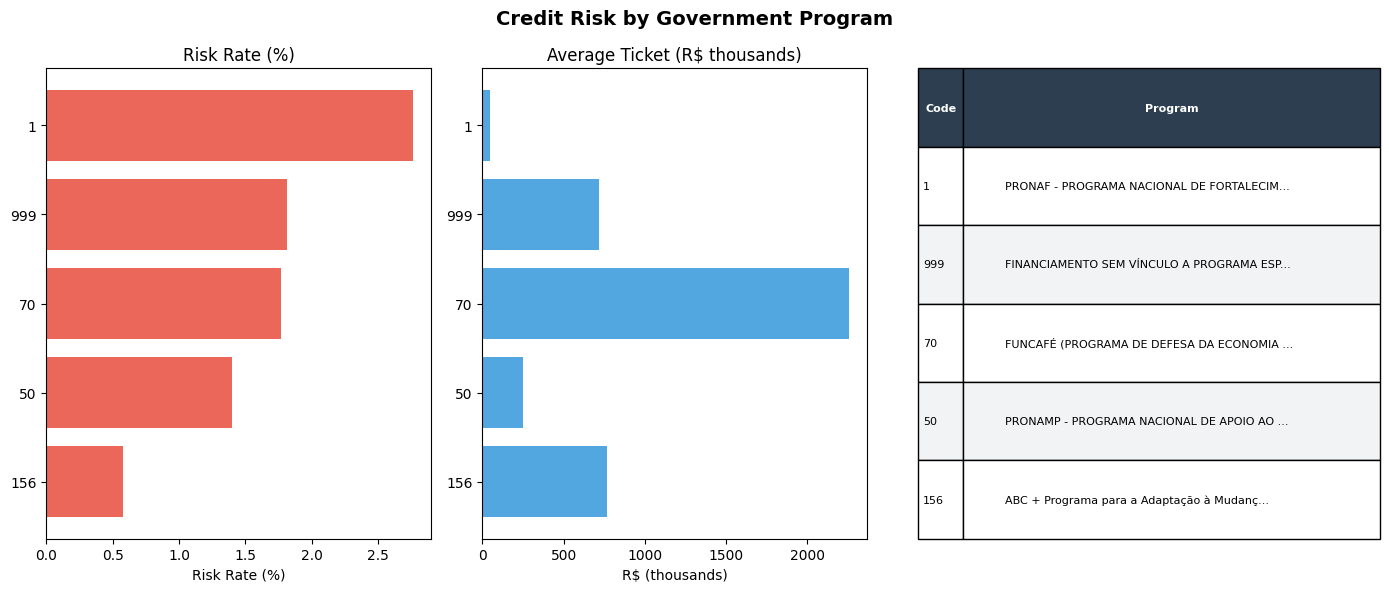

Saved!


In [33]:
# Cell 18 — BQ6 Visualization
fig = plt.figure(figsize=(14, 6))
fig.suptitle("Credit Risk by Government Program", fontsize=14, fontweight="bold")

gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.2])
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

labels_num = df_bq6["id_programa"].astype(str)

# Chart 1 — Risk rate
ax1.barh(labels_num, df_bq6["taxa_risco_pct"], color="#E74C3C", alpha=0.85)
ax1.set_title("Risk Rate (%)")
ax1.set_xlabel("Risk Rate (%)")
ax1.invert_yaxis()

# Chart 2 — Average ticket
ax2.barh(labels_num, df_bq6["ticket_medio"] / 1000, color="#3498DB", alpha=0.85)
ax2.set_title("Average Ticket (R$ thousands)")
ax2.set_xlabel("R$ (thousands)")
ax2.invert_yaxis()

# Legend table
ax3.axis("off")
table_data = [[str(row["id_programa"]), row["programa_label"]]
              for _, row in df_bq6.iterrows()]
table = ax3.table(
    cellText=table_data,
    colLabels=["Code", "Program"],
    cellLoc="left",
    loc="center",
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.auto_set_column_width([0, 1])

for j in range(2):
    table[0, j].set_facecolor("#2C3E50")
    table[0, j].set_text_props(color="white", fontweight="bold")

for i in range(1, len(table_data) + 1):
    for j in range(2):
        table[i, j].set_facecolor("#F2F3F4" if i % 2 == 0 else "white")

plt.tight_layout()
plt.savefig("../data/bq6_program_impact.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")